In [1]:
%matplotlib widget
#%matplotlib inline
import matplotlib.pyplot as plt
#from IPython.display import display
import numpy as np
import pandas as pd


In [2]:
# Load lattices
import xtrack as xt
env = xt.Environment()
env.call("00_lattice.py")
env.vars.load("011_matching_knobs/tme_matched_k1s.json")
env.vars.load("011_matching_knobs/fodow_matched_k1s.json")
env.vars.load("011_matching_knobs/ds_matched_k1s.json")
env.vars.load("011_matching_knobs/mds_matched_k1s.json")
env.vars.load("011_matching_knobs/pdr_k2s.json")  ## chromatic sext strengths: comment to also compute natural chromas

pdr_he = env['pdr']    ## pdr with hard-edge wiggler model
pdr_sb = env["pdr_sb"]    ## pdr with sinusoidal (splineboris) wiggler model

Slicing line:   0%|          | 0/512 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1584 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/2988 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/926 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/375 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/1628 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/375 [00:00<?, ?it/s]

## Twiss4d

In [3]:
############################################################################################
# twiss4d for optics and radiation integrals (from orbit curvature)
############################################################################################
tw4_he = pdr_he.twiss4d(radiation_integrals=True)  ## hard edge wiggler model
tw4_sb = pdr_sb.twiss4d(radiation_integrals=True)  ## sinusoidal (splineboris) wiggler model

keys_4d = [
    "qx", "qy",
    "dqx", "dqy",
    "momentum_compaction_factor",
    "slip_factor",
    "rad_int_i1x",
    "rad_int_i2",
    "rad_int_i3",
    "rad_int_i4x",
    "rad_int_i5x",
    "rad_int_eq_gemitt_x",
    "rad_int_damping_constant_x_s",
    "rad_int_damping_constant_y_s",
    "rad_int_damping_constant_zeta_s",
    "rad_int_partition_number_x",
    "rad_int_partition_number_y",
    "rad_int_partition_number_zeta",
]

pdr_4d_data = pd.DataFrame({
    "4dHE": {kk: getattr(tw4_he, kk) for kk in keys_4d},
    "4dSB": {kk: getattr(tw4_sb, kk) for kk in keys_4d},
})
pdr_4d_data["rel_diff_%"] = 100 * (pdr_4d_data["4dSB"] - pdr_4d_data["4dHE"]) / pdr_4d_data["4dHE"]

pd.options.display.float_format = "{:.6e}".format
pdr_4d_data
#############################################################################################

,4dHE,4dSB,rel_diff_%
qx,1.638762e+01,1.638779e+01,1.038948e-03
qy,1.225097e+01,1.226413e+01,1.073953e-01
dqx,-4.289770e-05,-6.504697e-04,1.416328e+03
dqy,3.451753e-03,-1.142567e+00,-3.320105e+04
momentum_compaction_factor,3.730167e-03,3.727807e-03,-6.327019e-02
slip_factor,3.730135e-03,3.727775e-03,-6.327073e-02
rad_int_i1x,1.496484e+00,1.496484e+00,7.145030e-09
rad_int_i2,2.906521e+00,2.825518e+00,-2.786938e+00
rad_int_i3,5.183342e-01,4.331250e-01,-1.643905e+01
rad_int_i4x,2.367914e-02,2.367914e-02,7.146572e-09


Text(0.5, 0.98, 'twiss4d sinusoidal')

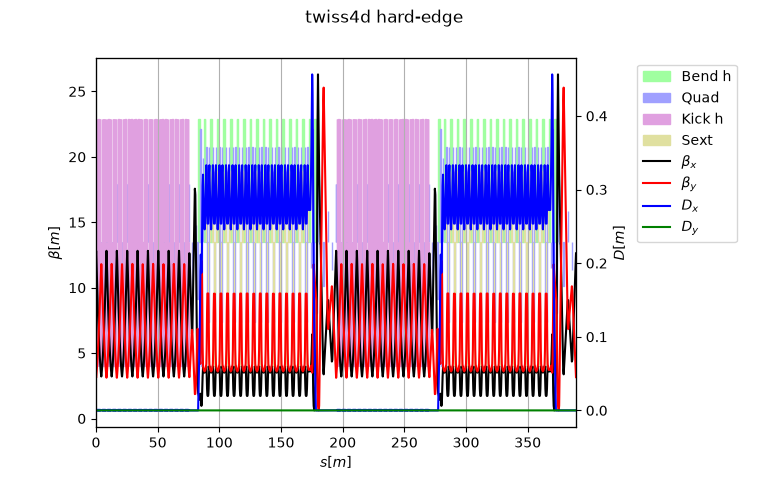

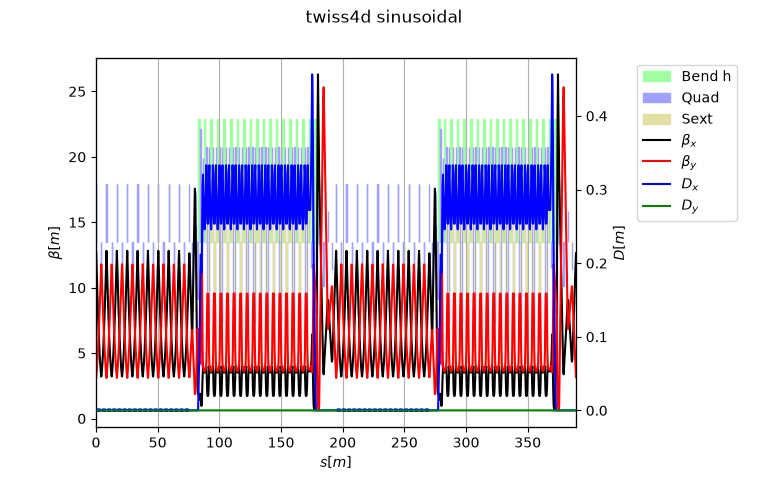

In [4]:
# Plots
tw4_he.plot().figure.suptitle('twiss4d hard-edge')
tw4_sb.plot().figure.suptitle('twiss4d sinusoidal')

# Twiss6d (hard-edge only)

In [5]:
# Insert time delay in cavity to compensate for z lag due to wiggling closed orbit.
z_lag=tw4_he.zeta[-1]
print(f"z_lag = {z_lag}")

env.elements['time_shift']=xt.TimeDelay(shift_zeta=z_lag)
pdr_he.append('time_shift')

z_lag = -0.0019837770588146727


In [ ]:
# Matched rf cavity
s_rf = 180.575 + 0.678 # = 181.253 m

from scipy.constants import c as clight
h=env["h"] #1298
V_rf = 10e6
lrf = 0

f_rf = h * clight / pdr_he.get_length()  ## frf=hfrev

In [ ]:
phi_s_rad_above=2.8642114091230484 ## matched rf phase: get from Line.compensate_radiation_energy_loss (or analytically)

In [ ]:
# Insert rf cavity
pdr_he.insert('rf_he',xt.Cavity(length=0,  ## thin cavity
                                    voltage=10e6, frequency=f_rf, 
                                    harmonic=0, phase=phi_s_rad_above) 
                                    ,at=s_rf, anchor='start')

Slicing line:   0%|          | 0/2603 [00:00<?, ?it/s]

In [ ]:
# Enable radiation 
pdr_he.discard_tracker()
pdr_he.configure_radiation(model='mean')
pdr_he.replace_all_repeated_elements()
pdr_he.build_tracker()
##pdr_he.compensate_radiation_energy_loss()

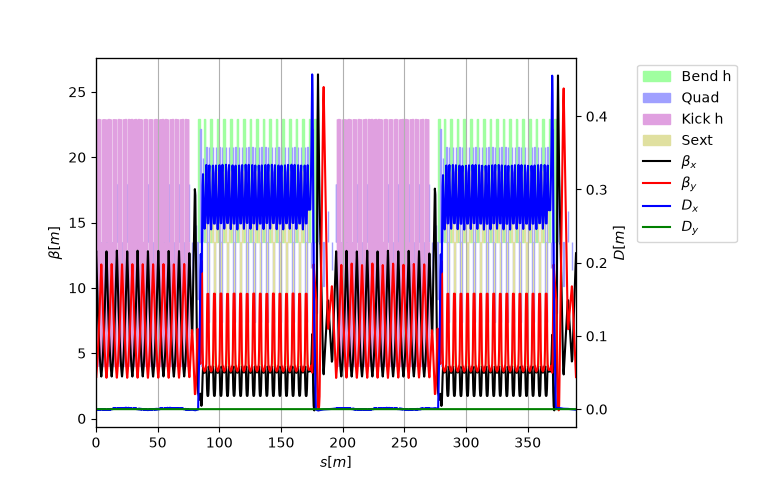

In [ ]:
# twiss6d and plot
tw6_he=env['pdr'].twiss(method='6d', radiation_analysis=True,)
tw6_he.plot()

In [11]:
####################################################################################################
# equilibrium parameters from 6d twiss (for hard-edge wiggler pdr only)
####################################################################################################
keys_6d = [
    "qs",
    "energy_loss",
    "eq_gemitt_x", "eq_gemitt_y", "eq_gemitt_zeta",
    "eq_nemitt_x", "eq_nemitt_y", "eq_nemitt_zeta",
]
vecs_6d = [
    "partition_numbers",
    "damping_constants_s",
    "damping_constants_turns",
]
planes = ["x", "y", "zeta"]

data_6d = {kk: getattr(tw6_he, kk) for kk in keys_6d}
data_6d.update({f"{kk}_{p}": v for kk in vecs_6d for p, v in zip(planes, getattr(tw6_he, kk))})

pdr_he_6d_data = pd.DataFrame({"6dHE": data_6d})

pd.options.display.float_format = "{:.6e}".format
pdr_he_6d_data
####################################################################################################


,6dHE
qs,5.112420e-02
energy_loss,2.738775e+06
eq_gemitt_x,1.181447e-08
eq_gemitt_y,1.980686e-49
eq_gemitt_zeta,4.835565e-06
eq_nemitt_x,6.612419e-05
eq_nemitt_y,1.108566e-45
eq_nemitt_zeta,2.706408e-02
partition_numbers_x,9.921085e-01
partition_numbers_y,1.000001e+00
